# Homework 5 solutions

## 1. nuclear reactions

We want to understand how tunneling allows fusion to occur in stars.

In [1]:
import unyt
import math

In [2]:
e = unyt.qe.in_cgs()
k = unyt.kb_cgs

### a.

Let's look at the classical method.  We have:

$$\frac{1}{2} \mu v^2 = \frac{3}{2}kT = \frac{e^2}{r_0}$$

where $r_0$ is the turning radius.  Solving for $T$, we find:

$$T = \frac{2}{3} \frac{e^2}{k r_0}$$

We can evaluate this for $r_0 = 1~\mathrm{fm}$

In [3]:
r0 = 1.0 * unyt.fm

In [4]:
T = 2./3. * e**2 / (k * r0)
T.in_cgs()

unyt_quantity(1.11400646e+10, 'K')

We see we need a temperature of $10^{10}~\mathrm{K}$ to fuse protons classically.

### b.

Now let's assume that fusion occurs when the protons are within a de Broglie wavelength of one-another.

We can write the kinetic energy in terms of de Broglie wavelength, $\lambda = h/p$:

$$\frac{p^2}{2\mu} = \left (\frac{h}{\lambda} \right )^2 \frac{1}{2\mu} = \frac{e^2}{\lambda}$$

where now we have evaluated the Coulomb potential at the de Broglie wavelength.  Solving
for $\lambda$, we have:

$$\lambda = \frac{h^2}{2 e^2 \mu}$$

Then we can use the same temperature expression as before, but with $r_0 \rightarrow \lambda$:

$$T = \frac{2}{3} \frac{e^2}{k \lambda} = \frac{4}{3} \frac{e^4\mu}{h^2 k}$$

In [5]:
mu = unyt.proton_mass.in_cgs() / 2
h = unyt.planck_constant_cgs

In [6]:
T = 4./3. * e**4 * mu / (h**2 * k)
T.in_cgs()

unyt_quantity(9791201.8459498, 'K')

Now we get a much more reasonable $10^7~\mathrm{K}$

### c.

Finally, let's estimate the neutrino flux at earth.  Most of the Sun's neutrinos are produced via the first $p + p$ reaction in the pp-chain, and overall we have:

$$4\, p \rightarrow {}^{4}\mathrm{He} + 2 e^+ + 2 \nu_e + 2\gamma$$

with the net energy equivalent to converting $\Delta m = 0.04 m_p$ into energy.

The number of reactions per second in the Sun is simply:

$$N = \frac{L_\odot}{E_\mathrm{react}} = \frac{L_\odot}{\Delta m c^2}$$

In [7]:
L = (1.0 * unyt.solar_luminosity).in_cgs()
dm = 0.03 * unyt.proton_mass_cgs
c = unyt.speed_of_light_cgs

N = L / (dm * c**2)
N

unyt_quantity(8.48589607e+37, 'erg*s/(cm**2*g)')

Now for each reaction, we get 2 neutrinos.  So the flux on earth is:

$$f_\nu = \frac{2 N_\mathrm{react}}{4 \pi d^2}$$

In [8]:
d = (1.0 * unyt.astronomical_unit).in_cgs()

f = 2 * N / (4 * math.pi * d**2)
f.in_cgs()

unyt_quantity(6.03485745e+10, '1/(cm**2*s)')

So about 60 billion neutrinos / square cm / second react earth.

## 2. radiative vs. convective cores

We want to see how the energy generation rate affects the temperature gradient and whether we are convective in the core of a star.

### a.

The adibatic temperature gradient is:

$$\left . \frac{dT}{dr} \right |_{ad} =
  \left (1 - \frac{1}{\gamma} \right ) \frac{T}{P} \frac{dP}{dr}$$

where we can use $\gamma$ for an ideal gas.

Now HSE says:

$$\frac{dP}{dr} = - \rho \frac{GM}{r^2}$$

and we need $M(r)$.  Near the core, expanding about $r = 0$, we have:

$$M(r) \sim \frac{4}{3} \pi r_0^3 \rho_c$$

so HSE becomes:

$$\frac{dP}{dr} = -\frac{4}{3}\pi r_0 G \rho_c^2$$

and our adiabatic temperature gradient is:

$$\left . \frac{dT}{dr} \right |_{ad} =
  \left (1 - \frac{1}{\gamma} \right ) \underbrace{\frac{\mu m_u}{\rho_c k}}_{T/P} \frac{4}{3}\pi r_0 G \rho_c^2$$

putting in $\gamma = 5/3$ and simplifying, this becomes:

$$\left . \frac{dT}{dr} \right |_{ad} = - \frac{8\pi}{15} r_0 G \rho_c \frac{\mu m_u}{k}$$


### b.

The temperature gradient needed to carry the entire flux via radiation is:

$$\left . \frac{dT}{dr} \right |_{rad} = - \frac{3}{4ac} \frac{\bar{\kappa}\rho}{T^3} \frac{L}{4\pi r^2}$$

using $L(r_0) \sim \frac{4}{3}\pi \rho_c r_0^3 \epsilon_c$, we have:

$$\left . \frac{dT}{dr} \right |_{rad} = - \frac{1}{4} \frac{\bar{\kappa}\rho_c^2 \epsilon_c r_0}{a c T_c^3}$$


### c.

Convection will result if

$$\left | \frac{dT}{dr} \right |_{rad} > \left | \frac{dT}{dr} \right |_{ad}$$

or, using our expressions above

$$\epsilon_c > \frac{32\pi}{15} \frac{Gac T_c^3 \mu m_u}{\bar{\kappa} \rho_c k}$$

```{note}
This shows that if the energy generation is large enough then convection will set in.
```

Now we can evaluate this.  Using:

$$\mu \sim \frac{4}{3 + 5X}$$

and taking $X \sim 0.7$ initially, we have $\mu \sim 0.6$.

Taking $T_c = T_6 = 10^6~\mathrm{K}$ and $\rho_c = \rho_2 = 100~\mathrm{g~cm^{-3}}$, we have:

$$\epsilon_c > 1.17 \left ( \frac{T_c}{T_6} \right )^3 \left (\frac{\rho_c}{\rho_2} \right )^{-1}~\mathrm{erg/g/s}$$

### d.

Now we can compare to the energy generation from the pp-chain,

$$\epsilon_{pp} = 2.4\times 10^4\, \rho X^2 T_9^{-2/3} e^{-3.38T_9^{-1/3}}~\mathrm{erg~g^{-1}~s^{1}}$$

Taking the conditions of the Sun, $T_9 = 0.015$, $\rho = 150~\mathrm{g~cm^{-3}}$, we have:

$$\epsilon_{pp} \sim 33~\mathrm{erg~g^{-1}~s^{-1}}$$

but

$$\epsilon_c > 2.3\times 10^3~\mathrm{erg~g^{-1}~s^{-1}}$$

for convection.

Therefore the Sun's core is not convective.

## 3. $\alpha$ network

We want to evolve the system:

  \begin{align*}
    \frac{dn_4}{dt} &= -\frac{3n_4^3}{6} \langle 3\alpha \rangle -
                          n_4 n_{12} \langle \alpha 12 \rangle -
                          n_4 n_{16} \langle \alpha 16 \rangle \\
    \frac{dn_{12}}{dt} &= \frac{n_4^3}{6} \langle 3\alpha \rangle -
                          n_4 n_{12} \langle \alpha 12 \rangle \\
    \frac{dn_{16}}{dt} &= n_4 n_{12} \langle \alpha 12 \rangle -
                          n_4 n_{16} \langle \alpha 16 \rangle \\
    \frac{dn_{20}}{dt} &= n_4 n_{16} \langle \alpha 16 \rangle 
  \end{align*}


The rates (from CF88) are:

* $\langle 3\alpha \rangle = \langle \sigma v \rangle$ for the 3-$\alpha$ reaction.
  We can find this expressed as $N_A^2 \langle \sigma v \rangle_{\alpha\alpha\alpha}$:

  \begin{equation*}
        N_A^2 \langle \sigma v \rangle_{\alpha\alpha\alpha} = \frac{2.79\times 10^{-8}}{T_9^3} \exp(-4.4027/T_9)
  \end{equation*}

* $\langle \alpha 12 \rangle =  \langle \sigma v \rangle$ for the
  ${}^{12}\mathrm{C}(\alpha,\gamma){}^{16}\mathrm{O}$ reaction.
  We find this expressed as $N_A \langle \sigma v \rangle_{C\alpha}$:

  \begin{align*}
        N_A \langle \sigma v \rangle_{C\alpha} = & 
           \frac{1.04\times 10^8}{T_9^2 (1.0 + 0.0489/T_9^{2/3})^2} 
              \exp(-32.120/T_9^{1/3} - (T_9/3.496)^2) + \nonumber \\
              & \frac{1.76\times 10^8}{T_9^2 (1.0+0.2654/T_9^{2/3})^2} 
                \exp(-32.120/T_9^{1/3}) + \nonumber \\
                &\frac{1.25\times 10^3}{T_9^{3/2}} \exp(-27.499/T_9) +
                1.43\times 10^{-2} T_9^5 \exp(-15.541/T_9)
  \end{align*}

*  $\langle \alpha 16 \rangle =  \langle \sigma v \rangle$ for the
   ${}^{16}\mathrm{O}(\alpha,\gamma){}^{20}\mathrm{Ne}$ reaction.  We find this expressed
   as $N_A \langle \sigma v \rangle_{O\alpha}$:

  \begin{align*}
        N_A \langle \sigma v \rangle_{O\alpha} = &
        \frac{9.37\times 10^9}{T_9^{2/3}} \exp(-39.757/T_9^{1/3}-(T_9/1.586)^2) + \nonumber \\
                 & \frac{6.21\times 10^1}{T_9^{3/2}} \exp(-10.297/T_9) + \nonumber \\
                 & \frac{5.38\times 10^2}{T_9^{3/2}} \exp(-12.226/T_9) + \nonumber \\
                 & 1.30\times 10^1 T_9^2 \exp(-20.093/T_9)
  \end{align*}


### a. Number density to molar fractions

As written our system is expressed in terms of number density.  Recall:

$$n_k = \frac{\rho X_k}{m_u A_k} = \frac{\rho Y_k}{m_u}$$

or using $N_A = 1/m_u$, we have:

$$n_k = \frac{\rho N_A X_k}{A_k} = \rho N_A Y_k$$

We'll work in terms of mass fractions, which have the property that

$$\sum_k X_k = 1$$

For example, to rewrite the evolution equation for ${}^{4}\mathrm{He}$, we could have:

\begin{align*}
\frac{N_A\rho}{A_4} \frac{dX_4}{dt} = &-\frac{1}{2} \left ( \frac{N_A \rho X_4}{A_4} \right )^3  \langle 3\alpha \rangle -
                          \left (\frac{N_A\rho X_4}{A_4} \right ) \left ( \frac{N_A\rho X_{12}}{A_{12}} \right ) \langle \alpha 12 \rangle \\ &-
                          \left ( \frac{N_A\rho  X_4}{A_4} \right ) \left (\frac{N_A\rho X_{16}}{A_{16}} \right ) \langle \alpha 16 \rangle
\end{align*}
                          
or simplifying:

$$\frac{dY_4}{dt} = -\frac{1}{2} \rho^2 Y_4^3 N_A^2  \langle 3\alpha \rangle -
                          \rho Y_4 Y_{12} N_A \langle \alpha 12 \rangle -
                          \rho Y_4 Y_{16} N_A \langle \alpha 16 \rangle$$

Note how $N_A$ enters with the rate is consistent with the expressions we were given above.

The system in terms of molar fractions becomes:

\begin{align*}
\frac{dY_4}{dt} &= -\frac{1}{2} \rho^2 Y_4^3 N_A^2  \langle 3\alpha \rangle -
                          \rho Y_4 Y_{12} N_A \langle \alpha 12 \rangle -
                          \rho Y_4 Y_{16} N_A \langle \alpha 16 \rangle \\
\frac{dY_{12}}{dt} &= \frac{1}{6} \rho^2 Y_4^3 N_A^2 \langle 3\alpha \rangle -
                       \rho Y_4 Y_{12} N_A \langle \alpha 12 \rangle \\
\frac{dY_{16}}{dt} &= \rho Y_4 Y_{12} N_A \langle \alpha 12 \rangle - 
                      \rho Y_4 Y_{16} N_A \langle \alpha 16 \rangle \\
\frac{dY_{20}}{dt} &= \rho Y_4 Y_{16} N_A \langle \alpha 16 \rangle
\end{align*}

### b. Integrating

Let's start by writing our RHS function.  We'll rely on the ODE solver to estimate the Jacobian.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def rhs(t, Y, rho, T, rc12ago16_factor=1.0):

    Y4  = Y[0]
    Y12 = Y[1]
    Y16 = Y[2]
    Y20 = Y[3]

    # temperature factors
    T9 = T/1.e9
    T913 = T9**(1./3.)
    T923 = T913**2
    T932 = T9**1.5

    # N_A**2 <sigma v> for 3-alpha from CF88 for T9 > 0.08
    r3a = 2.79e-8 / T9**3 * np.exp(-4.4027 / T9)

    # N_A <sigma v> for C12(a,g)O16
    rc12ago16 = (1.04e8 / T9**2 / (1.0 + 0.0489 / T923)**2 *
                 np.exp(-32.120 / T913 - (T9/3.496)**2) + 1.76e8 / T9**2 / (1.0 + 0.2654 / T923)**2 *
                 np.exp(-32.120 / T913) + 1.25e3 / T932 * np.exp(-27.499 / T9) +
                 1.43e-2 * T9**5 * np.exp(-15.541 / T9))
    rc12ago16 *= rc12ago16_factor
    
    # N_A <sigma v> for O16(a,g)Ne20
    ro16agne20 = (9.37e9 / T923 * np.exp(-39.757 / T913 - (T9 / 1.586)**2) + 
                  6.21e1 / T932 * np.exp(-10.297 / T9) + 5.38e2 / T932 * np.exp(-12.226 / T9) +
                  1.30e1 * T9**2 * np.exp(-20.093 / T9))

    dY4dt = -(1./2.) * rho**2 * Y4**3 * r3a - rho * Y4 * Y12 * rc12ago16 - rho * Y4 * Y16 * ro16agne20
    dY12dt = (1./6.) * rho**2 * Y4**3 * r3a - rho * Y4 * Y12 * rc12ago16
    dY16dt = rho * Y4 * Y12 * rc12ago16 - rho * Y4 * Y16 * ro16agne20
    dY20dt = rho * Y4 * Y16 * ro16agne20

    return np.array([dY4dt, dY12dt, dY16dt, dY20dt])

We can already investigate timescales for the burning&mdash;consider starting off with pure He, the timescale to consume the helium is:

$$\tau_\mathrm{burn} \sim \frac{Y_0({}^{4}\mathrm{He})}{|dY({}^{4}\mathrm{He})/dt|}$$

Let's plot this for $\rho = 10^5~\mathrm{g~cm^{-3}}$ as a function of temperature.

Where we note that $Y_0({}^4\mathrm{He}) = 1/4$, since the atomic weight is 4.

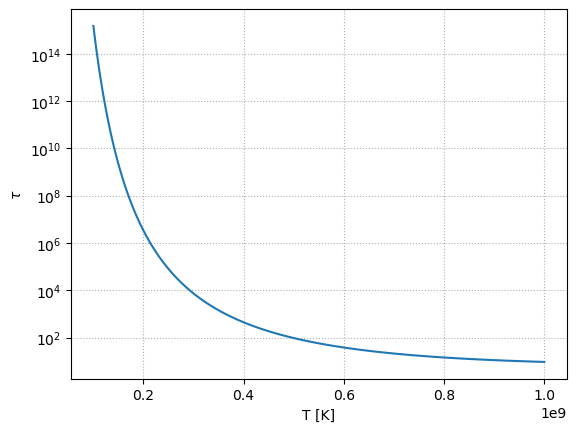

In [11]:
fig, ax = plt.subplots()

rho = 1.e5
Y = np.array([0.25, 0.0, 0.0, 0.0])
T = np.logspace(8., 9, 100)

tau = []
for TT in T:
    dYdt = rhs(0.0, Y, rho, TT)
    tau.append(Y[0] / np.abs(dYdt[0]))

ax.semilogy(T, tau)
ax.set_xlabel("T [K]")
ax.set_ylabel(r"$\tau$")
ax.grid(ls=":")

Note how strong the temperature dependence is.  At the low end, $T_9 = 8$, the timescale to burn is $> 10^{14}$ s, while at the high end, it is $\sim 10^2$ s.

Note that this is only an estimate&mdash;once we make C and O, more He will be consumed, further shortening this timescale, but those nuclei will have longer timescales to be consumed.

Now we can integrate the system.  We'll use the SciPy `solve_ivp` function.  Note that this network is stiff, so we will use the `"BDF"` method.

In [12]:
from scipy.integrate import solve_ivp

In [13]:
def he_exhaustion(t, y, *args, **kwargs):
    # He is the first species
    return y[0] - 1.e-7

he_exhaustion.terminal = True
he_exhaustion.direction = -1

def integrate(t_end, Y0, rho, T, rc12ago16_factor=1.0):

    sol = solve_ivp(rhs, [0, t_end], Y0, method="BDF",
                    dense_output=True, args=(rho, T, rc12ago16_factor),
                    events=he_exhaustion,
                    rtol=1.e-8, atol=1.e-10)

    return sol.t, sol.y

### c. Plotting

Let's write a simple function to plot the species

In [14]:
def plot(t_out, X_out):
    fig, ax = plt.subplots()

    ax.plot(t_out, X_out[0,:], label=r"${}^4\mathrm{He}$")
    ax.plot(t_out, X_out[1,:], label=r"${}^{12}\mathrm{C}$")
    ax.plot(t_out, X_out[2,:], label=r"${}^{16}\mathrm{O}$")
    ax.plot(t_out, X_out[3,:], label=r"${}^{20}\mathrm{Ne}$")

    ax.legend(frameon=False, loc="best")
    ax.set_ylim(1.e-10, 2)
    ax.grid(ls=":")
    ax.set_xlabel("t (s)")
    ax.set_ylabel("X")
    ax.set_xscale("log")
    ax.set_yscale("log")
    
    return fig

We want to plot mass fractions, so let's make an array of atomic weights

In [15]:
A = np.array([4.0, 12.0, 16.0, 20.0])

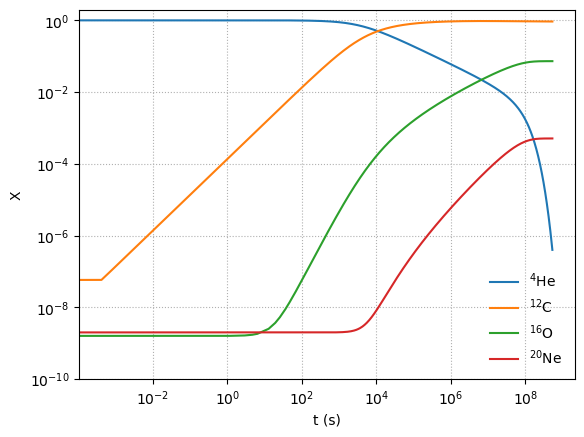

In [16]:
Y0 = np.array([0.25, 1.e-10, 1.e-10, 1.e-10])

rho = 1.e5
T = 3e8

tmax = 1.e12

t_out, Y_out = integrate(tmax, Y0, rho, T)

# convert to mass fractions
X_out = np.zeros_like(Y_out)
X_out[0, :] = Y_out[0, :] * A[0]
X_out[1, :] = Y_out[1, :] * A[1]
X_out[2, :] = Y_out[2, :] * A[2]
X_out[3, :] = Y_out[3, :] * A[3]

fig = plot(t_out, X_out)

Notice that as He is consumed, initially we build up C, but once there is enough C, we start to make O and then a little Ne.

What happens at higher T?

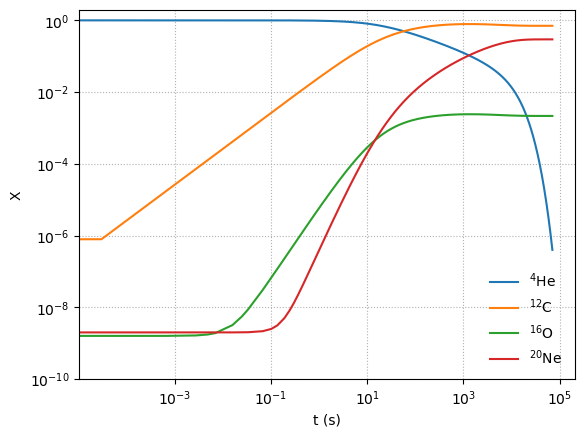

In [17]:
Y0 = np.array([0.25, 1.e-10, 1.e-10, 1.e-10])

rho = 1.e5
T = 6e8

tmax = 1.e12

t_out, Y_out = integrate(tmax, Y0, rho, T)

# convert to mass fractions
X_out = np.zeros_like(Y_out)
X_out[0, :] = Y_out[0, :] * A[0]
X_out[1, :] = Y_out[1, :] * A[1]
X_out[2, :] = Y_out[2, :] * A[2]
X_out[3, :] = Y_out[3, :] * A[3]

fig = plot(t_out, X_out)

Now we've made a lot of ${}^{20}\mathrm{Ne}$! and the timescale are overall much shorter.

But we note that at these temperatures were are starting to miss some other important rates, especially
those involving ${}^{12}\mathrm{C} + {}^{12}\mathrm{C}$

### d. Rate sensitivity

Let's explore what happens to the ${}^{12}\mathrm{C}(\alpha,\gamma){}^{16}\mathrm{O}$ rate, but
multiplying it by 1.7 as suggested in Weaver & Woosley 1993.

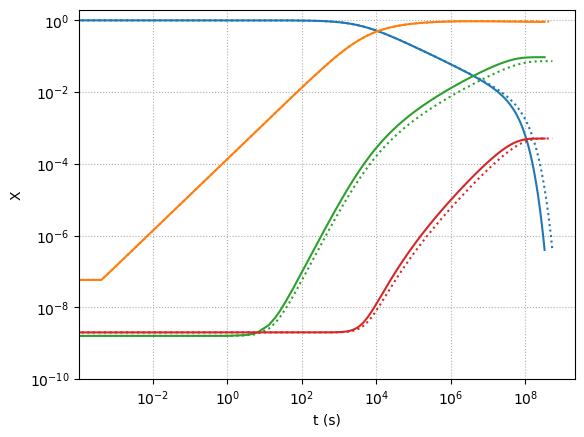

In [18]:
Y0 = np.array([0.25, 1.e-10, 1.e-10, 1.e-10])

rho = 1.e5
T = 3e8

tmax = 1.e12

t_out, Y_out = integrate(tmax, Y0, rho, T, rc12ago16_factor=1.7)

# convert to mass fractions
X_out = np.zeros_like(Y_out)
X_out[0, :] = Y_out[0, :] * A[0]
X_out[1, :] = Y_out[1, :] * A[1]
X_out[2, :] = Y_out[2, :] * A[2]
X_out[3, :] = Y_out[3, :] * A[3]

t_orig, Y_orig = integrate(tmax, Y0, rho, T, rc12ago16_factor=1.0)

# convert to mass fractions
X_orig = np.zeros_like(Y_orig)
X_orig[0, :] = Y_orig[0, :] * A[0]
X_orig[1, :] = Y_orig[1, :] * A[1]
X_orig[2, :] = Y_orig[2, :] * A[2]
X_orig[3, :] = Y_orig[3, :] * A[3]

fig, ax = plt.subplots()

ax.plot(t_out, X_out[0, :], label="He", color="C0")
ax.plot(t_orig, X_orig[0, :], linestyle=":", color="C0")

ax.plot(t_out, X_out[1, :], label="C", color="C1")
ax.plot(t_orig, X_orig[1, :], linestyle=":", color="C1")

ax.plot(t_out, X_out[2, :], label="O", color="C2")
ax.plot(t_orig, X_orig[2, :], linestyle=":", color="C2")

ax.plot(t_out, X_out[3, :], label="Ne", color="C3")
ax.plot(t_orig, X_orig[3, :], linestyle=":", color="C3")

ax.set_yscale("log")
ax.set_xscale("log")

ax.set_xlabel("t (s)")
ax.set_ylabel("X")

ax.set_ylim(1.e-10, 2)
ax.grid(ls=":")

Here we see the difference when we run with the enhanced rate (solid lines) -- we make slightly more oxygen.

### e. Energy release

We can get the energy release from the change in molar abundances over the burn.

We'll do this as:

$$\epsilon = -N_A c^2 \sum_k \frac{\Delta Y_k}{\Delta t} m_k$$

where $m_k$ is the mass of nucleus $k$.  This is effectively just accumulating the $\Delta m c^2$ from
the different reactions.  The end result will be in units of energy / mass / time.

We can get the mass in terms of the mass excess as:

$$m_k = A_k m_u + \frac{\Delta M_k}{c^2}$$

Here are the mass excesses from AME2020

In [19]:
from scipy import constants

keV2erg = (constants.eV * constants.kilo) / constants.erg
m_u = constants.value("unified atomic mass unit") * constants.kilo
c = constants.speed_of_light / constants.centi
N_A = constants.Avogadro

In [20]:
dm = np.array([2424.91587,  # He4
               0.0,  # C12
               -4737.00217,  # O16
               -7041.9322    # Ne20
              ])

# let's get masses in grams
mass = A * m_u + dm * keV2erg / c**2
mass

array([6.64647908e-24, 1.99264688e-23, 2.65601806e-23, 3.31982280e-23])

we'll redo our original burn

In [21]:
Y0 = np.array([0.25, 1.e-10, 1.e-10, 1.e-10])

rho = 1.e5
T = 3e8

tmax = 1.e12

t_out, Y_out = integrate(tmax, Y0, rho, T)

Npw we can compute the energy release

In [22]:
dY = np.zeros_like(Y0)
for i in range(len(dY)):
    dY[i] = Y_out[i, -1] - Y_out[i, 0]

eps = 0.0
for i in range(len(dY)):
    eps -= N_A * c**2 * mass[i] * dY[i]
    
eps /= t_out[-1]
eps

np.float64(1139198402.680193)

This shows that our *average* energy generation rate was about $10^9~\mathrm{erg/g/s}$